Set parameter TimeLimit to value 30
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M3 Pro
Thread count: 11 physical cores, 11 logical processors, using up to 11 threads

Non-default parameters:
TimeLimit  30

Optimize a model with 383 rows, 439 columns and 2244 nonzeros
Model fingerprint: 0x0499adfe
Variable types: 0 continuous, 439 integer (420 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+02]
  Objective range  [1e+00, 9e+00]
  Bounds range     [1e+00, 2e+01]
  RHS range        [1e+00, 3e+02]
Found heuristic solution: objective 4.0000000
Presolve removed 0 rows and 21 columns
Presolve time: 0.00s
Presolved: 383 rows, 418 columns, 2202 nonzeros
Variable types: 0 continuous, 418 integer (399 binary)

Root relaxation: objective 8.197690e+01, 217 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd

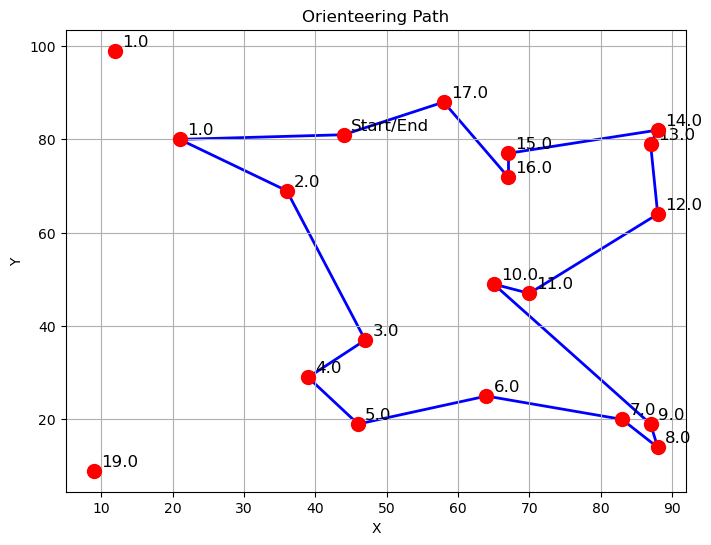

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import gurobipy as gp

# ----- data -----
# number of customers
n = 20

# generate locations
np.random.seed(0)
loc_x = np.random.randint(0, 100, n)
loc_y = np.random.randint(0, 100, n)

# generate scores
s = np.random.randint(1, 10, n)

# calculate travel time
c = {(i,j):((loc_x[i] - loc_x[j])**2 + (loc_y[i] - loc_y[j])**2)**.5
     for i in range(n) for j in range(n)}

# time budget
T = 300

# create model
model = gp.Model("Orienteering")

# 决策变量
x = model.addVars(n, n, vtype=gp.GRB.BINARY, name="x")
y = model.addVars(n, vtype=gp.GRB.BINARY, name="y")

for i in range(n):
    x[i,i].ub = 0 # no self-loops

# 目标函数：最大化得分
model.setObjective(gp.quicksum(s[i] * y[i] for i in range(1, n)), gp.GRB.MAXIMIZE)

# 起点出发一次，回到起点一次
model.addConstr(gp.quicksum(x[0,j] for j in range(n)) == 1)
model.addConstr(gp.quicksum(x[i,0] for i in range(n)) == 1)

# 约束：每个点最多进出一次
for i in range(1, n):
     model.addConstr(gp.quicksum(x[i,j] for j in range(n)) == y[i])
     model.addConstr(gp.quicksum(x[j,i] for j in range(n)) == y[i])

# 总时间约束
model.addConstr(gp.quicksum(c[i,j] * x[i,j] for i in range(n) for j in range(n)) <= T)

# MTZ 防止子回路（subtour）
u = model.addVars(range(1, n), lb=1, ub=n-1, vtype=gp.GRB.INTEGER, name="u")
for i in range(1, n):
     for j in range(1, n):
          if i != j:
               model.addConstr(u[i] - u[j] + n * x[i,j] <= n - 1)

# 求解模型
model.params.timelimit = 30
model.optimize()


# 输出结果
if model.status == gp.GRB.OPTIMAL:
     print("Optimal objective value:", model.ObjVal)
     print("The MIP gap is:", model.MIPGap)
     print("The known bound is:", model.ObjBound)
else:
     print("No optimal solution found")

# 可视化路径
if model.status == gp.GRB.OPTIMAL:
     selected = [(i, j) for i in range(n) for j in range(n) if x[i,j].X > 0.9]

     plt.figure(figsize=(8, 6))
     plt.scatter(loc_x, loc_y, c='red', s=100, zorder=5)

     plt.text(loc_x[0] + 1, loc_y[0] + 1, "Start/End", fontsize=12, zorder=5)
     
     for i in range(1, n):
          plt.text(loc_x[i] + 1, loc_y[i] + 1, str(u[i].X), fontsize=12)

     for (i, j) in selected:
          plt.plot([loc_x[i], loc_x[j]], [loc_y[i], loc_y[j]], 'b-', lw=2, zorder=1)

     plt.title("Orienteering Path")
     plt.xlabel("X")
     plt.ylabel("Y")
     plt.grid(True)
     plt.show()